In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Для работы с CUDA используется библиотека CuPy
import cupy as cp

In [3]:
# Тип используемого GPU
!nvidia-smi

Tue Mar 31 21:22:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# Тип используемого CPU
!lscpu | grep "Model name"

Model name:                              Intel(R) Xeon(R) CPU @ 2.00GHz


In [5]:
# Вспомогательный метод для заполнения матриц

def create_random_matrix(dim_size):

    return np.random.rand(dim_size, dim_size).astype(np.float32)

In [6]:
# Код на C++ для CUDA - ядра
cuda_matmul_src = r'''
extern "C" __global__
void device_matmul(const float* mat_left, const float* mat_right, float* mat_out, int dim_n, int dim_m, int dim_k)
{
    // Вычисление индекса строки (r) первой и столбца (c) второй исходных матриц в отдельном потоке

    int r = blockIdx.y * blockDim.y + threadIdx.y;
    int c = blockIdx.x * blockDim.x + threadIdx.x;

    if (r < dim_n && c < dim_k)
    {
        float accumulator = 0.0f;

        for (int idx = 0; idx < dim_m; idx++)
        {
            accumulator += mat_left[r * dim_m + idx] * mat_right[idx * dim_k + c];
        }

        mat_out[r * dim_k + c] = accumulator;
    }
}
'''
compiled_kernel = cp.RawKernel(cuda_matmul_src, 'device_matmul')

In [7]:
# Код для перемножения матриц на GPU

def compute_matmul_GPU(left_matrix, right_matrix):
    dim_n, dim_m = left_matrix.shape
    _, dim_k = right_matrix.shape

    # Перенос данных обеих матриц в память GPU
    GPU_left = cp.asarray(left_matrix)
    GPU_right = cp.asarray(right_matrix)
    GPU_out = cp.zeros((dim_n, dim_k), dtype=cp.float32)

    # Конфигурация сетки блоков (256 потоков на блок)
    threads_per_block = (16, 16)
    blocks_per_grid = (
        (dim_k + threads_per_block[0] - 1) // threads_per_block[0],
        (dim_n + threads_per_block[1] - 1) // threads_per_block[1]
    )

    # Запуск CUDA ядра
    compiled_kernel(blocks_per_grid, threads_per_block, (GPU_left, GPU_right, GPU_out, dim_n, dim_m, dim_k))

    # Возвращение результата для GPU
    return cp.asnumpy(GPU_out)

In [8]:
# Код для перемножения матриц на CPU

def compute_matmul_CPU(left_matrix, right_matrix):

    n_rows_left = left_matrix.shape[0]
    n_cols_left = left_matrix.shape[1]
    n_rows_right = right_matrix.shape[0]
    n_cols_right = right_matrix.shape[1]

    # Проверка размерностей
    if n_cols_left != n_rows_right:
        raise ValueError("Размерности требуемых матриц не совпадают")

    CPU_out = np.zeros((n_rows_left, n_cols_right), dtype=np.float32)

    # Алгоритм подсчета значений результирующей матрицы (Сложность по времени O(N^3))
    for r in range(n_rows_left):
        for c in range(n_cols_right):
            for idx in range(n_cols_left):
                CPU_out[r][c] += left_matrix[r][idx] * right_matrix[idx][c]

    # Возвращение результата для CPU
    return CPU_out

In [9]:
# Подсчет времени выполнения перемножения на CPU

def measure_CPU_performance(left_matrix, right_matrix):

    t_start = time.time()
    result = compute_matmul_CPU(left_matrix, right_matrix)
    t_end = time.time()

    return result, (t_end - t_start)

In [10]:
# Подсчет времени выполнения перемножения на GPU

def measure_GPU_performance(left_matrix, right_matrix):

    t_start = time.time()
    result = compute_matmul_GPU(left_matrix, right_matrix)
    cp.cuda.Stream.null.synchronize()
    t_end = time.time()

    return result, (t_end - t_start)

In [11]:
# Проверка поэлементного совпадения результирующих матриц  CPU/GPU с заданной точностью

def validate_correctness(out_CPU, out_GPU, tolerance=1e-4):

    return np.allclose(out_CPU, out_GPU, atol=tolerance)

In [12]:
# Подсчет времени выполнения и величины ускорения

def orchestrate_benchmarks(dim_list):

    CPU_durations = []
    GPU_durations = []

    for dim in dim_list:

        # Создание двух исходных матриц на CPU
        CPU_left_matrix = create_random_matrix(dim)
        CPU_right_matrix = create_random_matrix(dim)

        # Перемножение на CPU
        res_CPU, duration_CPU = measure_CPU_performance(CPU_left_matrix, CPU_right_matrix)
        CPU_durations.append(duration_CPU)

        # Перемножение на GPU
        res_GPU, duration_GPU = measure_GPU_performance(CPU_left_matrix, CPU_right_matrix)
        GPU_durations.append(duration_GPU)

        # Проверка поэлементного совпадения матриц CPU/GPU
        if validate_correctness(res_CPU, res_GPU):
            validation_status = "PASS"
        else:
            validation_status = "FAIL"

        # Вычисление величины ускорения при распараллеливании умножения
        speedup = duration_CPU / duration_GPU if duration_GPU > 0 else 0

        print(f"Размерность каждой исходной матрицы: {dim}x{dim} | "
              f"CPU: {duration_CPU:.4f} сек | "
              f"GPU: {duration_GPU:.4f} сек | "
              f"Ускорение: {speedup:.2f} раз | "
              f"Корректность перемножения: {validation_status}")

    return CPU_durations, GPU_durations


In [13]:
# Построение графиков результатов перемножения
def visualize_benchmarks(dim_list, CPU_times, GPU_times):

    acceleration_factors = [h / d for h, d in zip(CPU_times, GPU_times)]

    fig, (ax_time, ax_speedup) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10))

    # График №1 - Значение времени перемножения матриц на CPU/GPU в секундах
    ax_time.plot(dim_list, CPU_times, label="CPU", marker='o', linewidth=2, color='darkred')
    ax_time.plot(dim_list, GPU_times, label="GPU", marker='s', linewidth=2, color='dodgerblue')

    ax_time.set_xlabel("Размерность матриц (NxN)", fontsize=11)
    ax_time.set_ylabel("Время выполнения (Сек)", fontsize=11)

    ax_time.set_title("Сравнение времени вычислений на CPU и GPU", fontsize=14, fontweight='bold')
    ax_time.grid(True, linestyle='--', alpha=0.6)
    ax_time.legend(loc='upper left', fontsize=11)

    # График №2 - Значение ускорения (кратного выигрыша во времени при параллелизации вычислений на GPU)
    ax_speedup.plot(dim_list, acceleration_factors, label="Ускорение", marker='^', linewidth=2, color='forestgreen')

    ax_speedup.set_xlabel("Размерность матриц (NxN)", fontsize=11)
    ax_speedup.set_ylabel("Ускорение (CPU / GPU)", fontsize=11)

    ax_speedup.set_title("Величина ускорения", fontsize=14, fontweight='bold')
    ax_speedup.grid(True, linestyle='--', alpha=0.6)
    ax_speedup.legend(loc='upper left', fontsize=11)

    # Вывод полученных графиков
    plt.tight_layout()
    plt.show()

Старт вычислений для матриц следующих размерностей: [100, 250, 500, 750, 1000, 1250]

Размерность каждой исходной матрицы: 100x100 | CPU: 0.8277 сек | GPU: 0.5514 сек | Ускорение: 1.50 раз | Корректность перемножения: PASS
Размерность каждой исходной матрицы: 250x250 | CPU: 15.2178 сек | GPU: 0.0009 сек | Ускорение: 16665.26 раз | Корректность перемножения: PASS
Размерность каждой исходной матрицы: 500x500 | CPU: 116.2826 сек | GPU: 0.0028 сек | Ускорение: 41632.48 раз | Корректность перемножения: PASS
Размерность каждой исходной матрицы: 750x750 | CPU: 393.9531 сек | GPU: 0.0089 сек | Ускорение: 44219.74 раз | Корректность перемножения: PASS
Размерность каждой исходной матрицы: 1000x1000 | CPU: 937.3307 сек | GPU: 0.0131 сек | Ускорение: 71473.11 раз | Корректность перемножения: PASS
Размерность каждой исходной матрицы: 1250x1250 | CPU: 1828.1978 сек | GPU: 0.0274 сек | Ускорение: 66828.34 раз | Корректность перемножения: PASS

Визуализация результатов работы программы


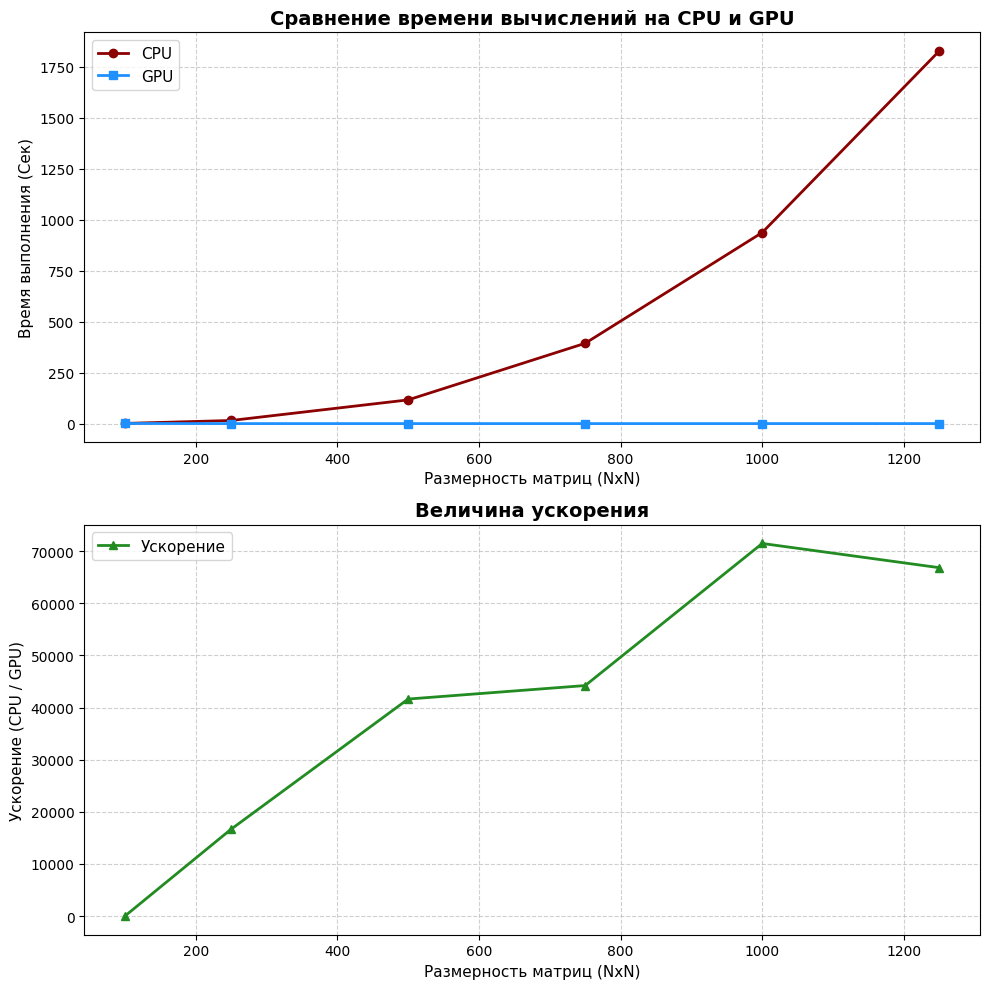

In [14]:
# Задание матриц размерностью: 100x100, 250x250, 500x500, 750x750, 1000x1000, 1250x1250
if __name__ == "__main__":

    matrix_dimensions = [100, 250, 500, 750, 1000, 1250]

    print(f"Старт вычислений для матриц следующих размерностей: {matrix_dimensions}\n")
    cpu_records, gpu_records = orchestrate_benchmarks(matrix_dimensions)

    print("\nВизуализация результатов работы программы")
    visualize_benchmarks(matrix_dimensions, cpu_records, gpu_records)